In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
%matplotlib inline 

import os
from datetime import datetime
import pandas as pd
import pandas_datareader.data as web 

from statsmodels.regression.rolling import RollingOLS 
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_style("whitegrid")
idx = pd.IndexSlice

In [5]:
df = pd.read_csv(os.path.join("..", "..", "data", "chile-stocks-close.csv"))
df = df.set_index("Date")
df.index = pd.to_datetime(df.index)
print(len(df))
df.head()

5215


,NAVARINO.SN,VOLCAN.SN,ENAEX.SN,CAMANCHACA.SN,CIC.SN,MOLYMET.SN,SMSAAM.SN,BSANTANDER.SN,PAZ.SN,CGET.SN,...,SALFACORP.SN,CTC.SN,COPEC.SN,FOSFOROS.SN,CCU.SN,SOCOVESA.SN,CONCHATORO.SN,CINTAC.SN,ZOFRI.SN,PEHUENCHE.SN
Date,,,,,,,,,,,,,,,,,,,,,
2005-12-29,1374.166138,733.996094,2065.921875,NaN,2.048007,1287.379272,NaN,10.618567,NaN,NaN,...,157.389816,NaN,4091.289062,499.554626,1042.445435,NaN,509.326416,95.958549,55.236153,333.404236
2005-12-30,1374.166138,750.307434,2065.921875,NaN,1.973176,1287.379272,NaN,10.285249,NaN,NaN,...,161.710327,NaN,4091.657715,499.523163,1064.973511,NaN,509.326416,97.255310,53.888905,353.523560
2006-01-02,1374.166138,750.307434,2065.921875,NaN,1.969237,1287.379272,NaN,10.285249,NaN,NaN,...,160.475891,NaN,4048.314941,499.523163,1042.182251,NaN,509.306244,97.255310,52.541706,353.523560
2006-01-03,1366.649414,750.307434,2065.921875,NaN,2.065730,1287.379272,NaN,10.618567,NaN,NaN,...,160.475891,NaN,4085.201660,471.574524,1056.686035,NaN,517.408081,96.931129,52.541706,353.523560
2006-01-04,1366.649414,740.986633,2065.921875,NaN,2.048007,1287.379272,NaN,10.618567,NaN,NaN,...,160.475891,NaN,4195.862305,471.574524,1077.405029,NaN,526.177612,96.931129,55.828930,353.523560


In [6]:
with pd.HDFStore(os.path.join("..", "..", "data", "assets.h5")) as store :
    store.put("prices/chile", df.sort_index())
    print(store.info())

<class 'pandas.io.pytables.HDFStore'>
File path: ..\..\data\assets.h5
/engineered_features            frame        (shape->[501517,34])
/prices/chile                   frame        (shape->[5215,120]) 


In [5]:
df.loc["2010-01-01" : "2011-01-01"]

,NAVARINO.SN,VOLCAN.SN,ENAEX.SN,CAMANCHACA.SN,CIC.SN,MOLYMET.SN,SMSAAM.SN,BSANTANDER.SN,PAZ.SN,CGET.SN,...,SALFACORP.SN,CTC.SN,COPEC.SN,FOSFOROS.SN,CCU.SN,SOCOVESA.SN,CONCHATORO.SN,CINTAC.SN,ZOFRI.SN,PEHUENCHE.SN
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-01,949.821289,675.742554,2993.478516,NaN,1.378466,6703.250977,NaN,14.637434,132.298233,NaN,...,536.359863,NaN,7056.208984,345.821381,1899.732056,110.843712,746.919800,162.092163,112.358391,890.994385
2010-01-04,949.821289,675.742554,2993.478516,NaN,1.437543,6703.250977,NaN,14.970752,129.841248,NaN,...,555.493469,NaN,7158.398438,345.821381,1929.766724,109.618217,764.615479,162.092163,113.166702,890.994385
2010-01-05,949.821289,685.063232,2934.536133,NaN,1.575390,6703.250977,NaN,15.027890,129.341843,NaN,...,552.382629,NaN,7138.774414,345.821381,1922.028931,109.618217,763.197021,162.092163,114.783371,888.120239
2010-01-06,949.821289,685.063232,3018.775391,NaN,1.575390,6703.250977,NaN,15.213597,128.842453,NaN,...,552.462952,NaN,7175.429688,345.821381,1930.250854,110.849869,756.240356,162.092163,116.130615,902.490723
2010-01-07,949.821289,685.063232,3027.208496,NaN,1.536005,6703.250977,NaN,15.446918,128.343063,NaN,...,552.407471,NaN,7344.360352,345.821381,1958.157227,112.081558,763.197021,162.092163,115.858498,890.994385
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010-12-27,614.992249,1070.911377,4958.395996,74.966209,2.973548,9736.721680,NaN,20.626295,255.048126,NaN,...,1036.921143,NaN,8330.949219,386.196411,2724.952148,221.699738,759.887573,257.868134,149.422165,919.808899
2010-12-28,614.992249,1070.911377,4958.395996,74.926224,2.973548,9694.724609,NaN,20.715519,256.786011,NaN,...,1030.378662,NaN,8231.755859,386.196411,2704.643799,221.699738,754.011475,256.542633,149.422165,922.785828
2010-12-29,614.992249,1070.911377,4958.395996,75.975899,2.973548,9729.571289,NaN,20.824575,259.118195,NaN,...,1043.093262,NaN,8361.655273,386.196411,2737.571289,227.858078,760.495239,256.549133,148.812256,922.785828


# Getting lag values

In [6]:
outlier_cutoff = 0.01
# data = pd.DataFrame(index = df.stack([0,1]).index)
# data.index.names = df.stack([0,1]).index.names
data = pd.DataFrame()
lags = [1, 2, 5, 20, 130, 260]
for lag in lags:
    data[f'return_{lag}d'] = (
        df
        .pct_change(lag)
        .stack()
        # .pipe(lambda x: x.clip(
        #     lower=x.quantile(outlier_cutoff),
        #     upper=x.quantile(1 - outlier_cutoff),
        # ))
        .add(1)
        .pow(1 / lag)
        .sub(1)
    )
    
data = data.swaplevel().dropna()
data.index = data.index.set_names(['ticker', 'Date' ])
print(data.info())
data.head()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 502858 entries, ('NAVARINO.SN', Timestamp('2006-12-28 00:00:00')) to ('PEHUENCHE.SN', Timestamp('2025-12-29 00:00:00'))
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   return_1d    502858 non-null  float64
 1   return_2d    502858 non-null  float64
 2   return_5d    502858 non-null  float64
 3   return_20d   502858 non-null  float64
 4   return_130d  502858 non-null  float64
 5   return_260d  502858 non-null  float64
dtypes: float64(6)
memory usage: 24.6+ MB
None


,,return_1d,return_2d,return_5d,return_20d,return_130d,return_260d
ticker,Date,,,,,,
NAVARINO.SN,2006-12-28,0.000000,0.000000,0.000000,0.010257,-0.000403,-0.001677
VOLCAN.SN,2006-12-28,0.000000,0.011561,0.004608,0.003537,0.001210,0.001286
ENAEX.SN,2006-12-28,-0.018868,0.000000,0.000000,-0.001885,0.001113,0.000229
CIC.SN,2006-12-28,0.000000,0.007565,-0.009339,0.002423,0.000246,0.000769
MOLYMET.SN,2006-12-28,0.000000,0.000000,0.000000,-0.000887,0.002618,0.005413


In [7]:
min_obs = 260 * 5 # five years
n_obs = data.groupby(level="ticker").size()
keep = n_obs[n_obs > min_obs].index

data = data.loc[idx[keep, :], :]
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 501517 entries, ('AGUAS-A.SN', Timestamp('2006-12-28 00:00:00')) to ('ZOFRI.SN', Timestamp('2025-12-29 00:00:00'))
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   return_1d    501517 non-null  float64
 1   return_2d    501517 non-null  float64
 2   return_5d    501517 non-null  float64
 3   return_20d   501517 non-null  float64
 4   return_130d  501517 non-null  float64
 5   return_260d  501517 non-null  float64
dtypes: float64(6)
memory usage: 24.6+ MB


In [8]:
data.describe()

,return_1d,return_2d,return_5d,return_20d,return_130d,return_260d
count,501517.000000,501517.000000,501517.000000,501517.000000,501517.000000,501517.000000
mean,0.000398,0.000298,0.000235,0.000204,0.000187,0.000173
std,0.021300,0.014608,0.009096,0.004552,0.001839,0.001345
min,-0.773824,-0.524420,-0.257170,-0.071627,-0.013270,-0.009524
25%,0.000000,-0.001319,-0.001848,-0.001333,-0.000662,-0.000482
50%,0.000000,0.000000,0.000000,0.000000,0.000068,0.000111
75%,0.000000,0.001193,0.001932,0.001639,0.001026,0.000853
max,3.300000,1.514663,0.537799,0.126083,0.016183,0.011896


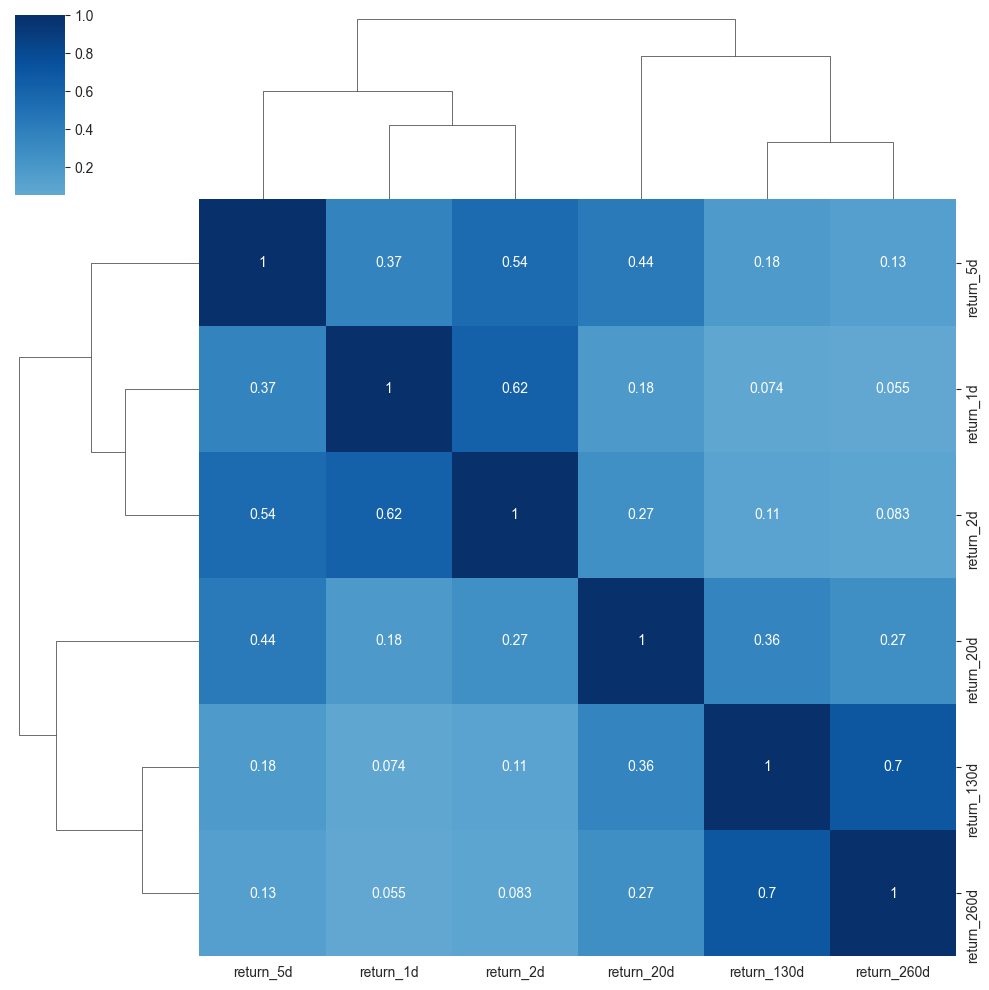

In [9]:
sns.clustermap(data.corr('spearman'), annot = True, center = 0, cmap = 'Blues')

In [10]:
data.index.get_level_values("ticker").nunique()

115

# Beta

# French fama factor, shows the exposure of a stock to the French Fama-French three factors

It can be a good indicator of value stocks performance in relation to the overall market.

In [11]:
factors = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
# Daily Fama-French 5 factors (Ken French daily data)
try:
    daily_factors = web.DataReader('F-F_Research_Data_5_Factors_2x3_Daily', 'famafrench', start='2004')[0]
except Exception:
    # Fallback to 3-factor daily set if 5-factor daily is unavailable
    daily_factors = web.DataReader('F-F_Research_Data_Factors_Daily', 'famafrench', start='2004')[0].drop(columns=['RF'])

# Drop risk-free and scale to decimals
daily_factors = daily_factors.drop(columns=['RF']).div(100)

# Ensure datetime index regardless of source index type
idx = daily_factors.index
if isinstance(idx, pd.PeriodIndex):
    daily_factors.index = idx.to_timestamp()
else:
    daily_factors.index = pd.to_datetime(idx)

daily_factors.index.name = 'Date'
print(daily_factors.info())
daily_factors.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5513 entries, 2004-01-02 to 2025-11-28
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Mkt-RF  5513 non-null   float64
 1   SMB     5513 non-null   float64
 2   HML     5513 non-null   float64
 3   RMW     5513 non-null   float64
 4   CMA     5513 non-null   float64
dtypes: float64(5)
memory usage: 258.4 KB
None


,Mkt-RF,SMB,HML,RMW,CMA
Date,,,,,
2004-01-02,-0.0017,0.0080,0.0042,-0.0058,0.0060
2004-01-05,0.0120,0.0026,0.0001,-0.0075,0.0082
2004-01-06,0.0020,0.0005,0.0027,-0.0047,0.0056
2004-01-07,0.0034,0.0053,-0.0008,-0.0052,0.0020
2004-01-08,0.0045,0.0029,0.0072,-0.0090,0.0095


In [12]:
daily_factors = daily_factors.join(data["return_1d"]).sort_index()
daily_factors.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 481536 entries, ('AGUAS-A.SN', Timestamp('2006-12-28 00:00:00')) to ('ZOFRI.SN', Timestamp('2025-11-28 00:00:00'))
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Mkt-RF     481536 non-null  float64
 1   SMB        481536 non-null  float64
 2   HML        481536 non-null  float64
 3   RMW        481536 non-null  float64
 4   CMA        481536 non-null  float64
 5   return_1d  481536 non-null  float64
dtypes: float64(6)
memory usage: 23.5+ MB


In [13]:
T = 40
betas = ( daily_factors.groupby(level = "ticker",
                                group_keys = False)
         .apply( lambda x : RollingOLS(endog = x.return_1d, 
                                       exog = sm.add_constant(x.drop('return_1d', axis = 1)),
                                       window = min(T, x.shape[0] - 1))
         .fit(params_only = True)
         .params
         .drop('const', axis = 1)
))
betas

Mkt-RF       SMB       HML       RMW       CMA
ticker     Date                                                        
AGUAS-A.SN 2006-12-28       NaN       NaN       NaN       NaN       NaN
           2006-12-29       NaN       NaN       NaN       NaN       NaN
           2007-01-03       NaN       NaN       NaN       NaN       NaN
           2007-01-04       NaN       NaN       NaN       NaN       NaN
           2007-01-05       NaN       NaN       NaN       NaN       NaN
...                         ...       ...       ...       ...       ...
ZOFRI.SN   2025-11-21 -0.053593  0.719392 -0.588445  0.375890  0.386040
           2025-11-24 -0.064127  0.698222 -0.594639  0.377289  0.456257
           2025-11-25 -0.092891  0.338798 -0.525485  0.191827  0.543618
           2025-11-26 -0.240584  0.519898 -0.492474  0.231926  0.322652
           2025-11-28 -0.205179  0.398355 -0.443208  0.141526  0.392124

[481536 rows x 5 columns]

In [14]:
betas.describe().join(betas.sum(1).describe().to_frame('total'))

,Mkt-RF,SMB,HML,RMW,CMA,total
count,477051.000000,477051.000000,4.770510e+05,477051.000000,4.770510e+05,4.815360e+05
mean,0.150778,-0.000620,1.406337e-02,-0.022041,-6.342025e-03,1.345732e-01
std,0.546390,0.852244,1.028005e+00,1.298797,1.547242e+00,2.523903e+00
min,-18.103156,-25.651515,-5.109973e+01,-137.430494,-5.994717e+01,-2.646879e+02
25%,-0.035375,-0.256594,-2.389649e-01,-0.376028,-4.287258e-01,-4.582606e-01
50%,0.050804,0.000000,4.463561e-17,0.000000,6.279522e-17,2.018769e-15
75%,0.348135,0.238387,3.056316e-01,0.342156,4.491617e-01,8.119726e-01
max,18.961595,42.675106,2.563829e+01,24.672268,3.238256e+01,4.935045e+01


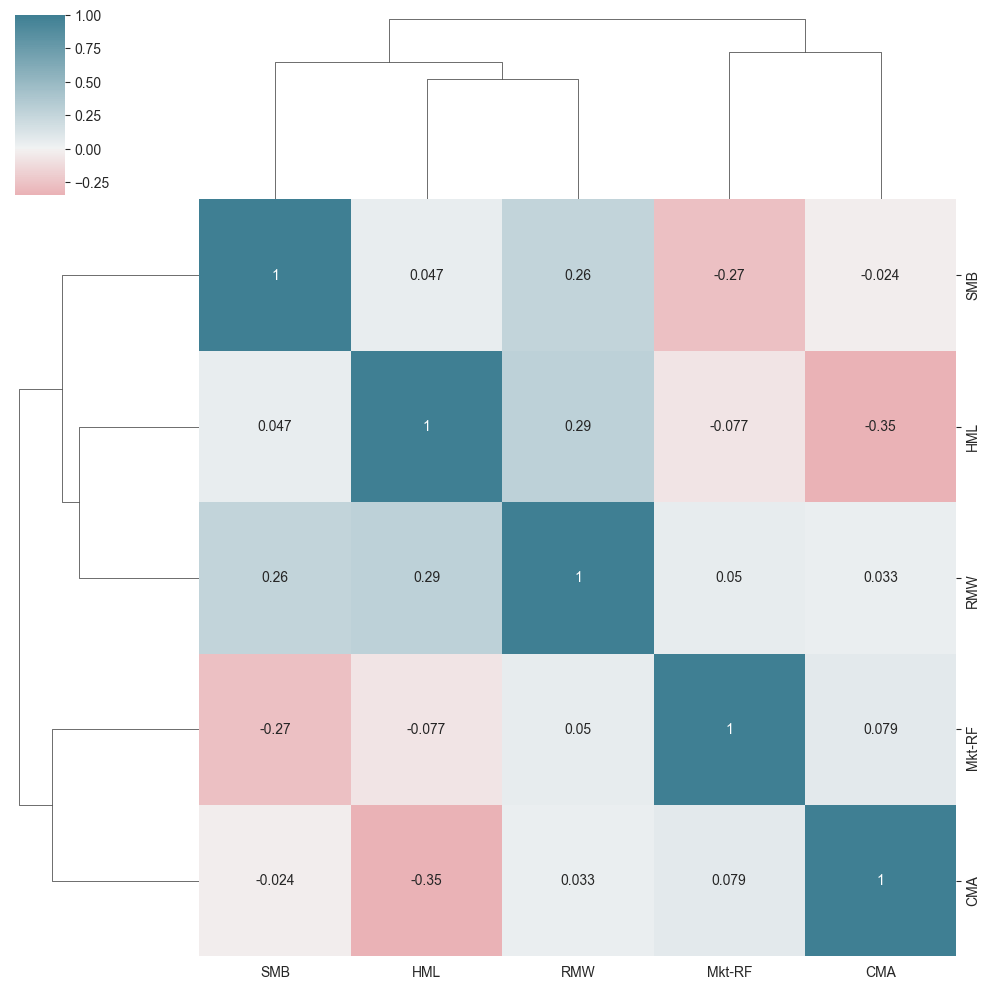

In [15]:
cmap = sns.diverging_palette(10, 220, as_cmap=True)
sns.clustermap(betas.corr(), annot=True, cmap=cmap, center=0);

In [16]:
betas.groupby(level = "ticker").shift()

Mkt-RF       SMB       HML       RMW       CMA
ticker     Date                                                        
AGUAS-A.SN 2006-12-28       NaN       NaN       NaN       NaN       NaN
           2006-12-29       NaN       NaN       NaN       NaN       NaN
           2007-01-03       NaN       NaN       NaN       NaN       NaN
           2007-01-04       NaN       NaN       NaN       NaN       NaN
           2007-01-05       NaN       NaN       NaN       NaN       NaN
...                         ...       ...       ...       ...       ...
ZOFRI.SN   2025-11-21 -0.136193  0.480065 -0.601715  0.222521  0.418293
           2025-11-24 -0.053593  0.719392 -0.588445  0.375890  0.386040
           2025-11-25 -0.064127  0.698222 -0.594639  0.377289  0.456257
           2025-11-26 -0.092891  0.338798 -0.525485  0.191827  0.543618
           2025-11-28 -0.240584  0.519898 -0.492474  0.231926  0.322652

[481536 rows x 5 columns]

In [17]:
pd.Series([1,2,3]).shift()

0    NaN
1    1.0
2    2.0
dtype: float64

In [18]:
data = (data
        .join(betas
              .groupby(level='ticker')
              .shift()))
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 501517 entries, ('AGUAS-A.SN', Timestamp('2006-12-28 00:00:00')) to ('ZOFRI.SN', Timestamp('2025-12-29 00:00:00'))
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   return_1d    501517 non-null  float64
 1   return_2d    501517 non-null  float64
 2   return_5d    501517 non-null  float64
 3   return_20d   501517 non-null  float64
 4   return_130d  501517 non-null  float64
 5   return_260d  501517 non-null  float64
 6   Mkt-RF       476936 non-null  float64
 7   SMB          476936 non-null  float64
 8   HML          476936 non-null  float64
 9   RMW          476936 non-null  float64
 10  CMA          476936 non-null  float64
dtypes: float64(11)
memory usage: 59.8+ MB


### Impute mean for missing factor betas

In [20]:
data[factors] = data.groupby(level="ticker")[factors].transform(lambda x: x.fillna(x.mean()))

# Momentum factors

In [21]:
for lag in [1, 2, 5, 20, 130, 260]:
    data[f"momentum_{lag}"] = data[f'return_{lag}d'].sub(data.return_1d)
data[f'momentum_130_260'] = data[f'return_260d'].sub(data.return_130d)

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 501517 entries, ('AGUAS-A.SN', Timestamp('2006-12-28 00:00:00')) to ('ZOFRI.SN', Timestamp('2025-12-29 00:00:00'))
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   return_1d         501517 non-null  float64
 1   return_2d         501517 non-null  float64
 2   return_5d         501517 non-null  float64
 3   return_20d        501517 non-null  float64
 4   return_130d       501517 non-null  float64
 5   return_260d       501517 non-null  float64
 6   Mkt-RF            501517 non-null  float64
 7   SMB               501517 non-null  float64
 8   HML               501517 non-null  float64
 9   RMW               501517 non-null  float64
 10  CMA               501517 non-null  float64
 11  momentum_1        501517 non-null  float64
 12  momentum_2        501517 non-null  float64
 13  momentum_5        501517 non-null  float64
 14  momentum_20       501517 non-

# Date indicators

In [24]:
dates = data.index.get_level_values("Date")

In [29]:
data["day"] = dates.day
data["year"] = dates.year
data['month'] = dates.month
data['weekday'] = dates.dayofweek

# Lagged returns

In [31]:
for t in range(1, 7):
    data[f'return_1d_t-{t}'] = data.groupby(level='ticker').return_1d.shift(t)
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 501517 entries, ('AGUAS-A.SN', Timestamp('2006-12-28 00:00:00')) to ('ZOFRI.SN', Timestamp('2025-12-29 00:00:00'))
Data columns (total 28 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   return_1d         501517 non-null  float64
 1   return_2d         501517 non-null  float64
 2   return_5d         501517 non-null  float64
 3   return_20d        501517 non-null  float64
 4   return_130d       501517 non-null  float64
 5   return_260d       501517 non-null  float64
 6   Mkt-RF            501517 non-null  float64
 7   SMB               501517 non-null  float64
 8   HML               501517 non-null  float64
 9   RMW               501517 non-null  float64
 10  CMA               501517 non-null  float64
 11  momentum_1        501517 non-null  float64
 12  momentum_2        501517 non-null  float64
 13  momentum_5        501517 non-null  float64
 14  momentum_20       501517 non-

# Target: Holding Period Returns

Similarly, to compute returns for various holding periods, we use the normalized period returns computed previously and shift them back to align them with the current financial features

In [32]:
for t in [1, 2, 5, 20, 130, 260]:
    data[f'target_{t}d'] = data.groupby(level='ticker')[f'return_{t}d'].shift(-t)

In [34]:
cols = ['target_1d',
        'target_2d',
        'target_5d', 
        'return_1d',
        'return_2d',
        'return_5d',
        'return_1d_t-1',
        'return_1d_t-2',
        'return_1d_t-3']

data[cols].dropna().sort_index().head(10)

target_1d  target_2d  target_5d  return_1d  return_2d  \
ticker     Date                                                                
AGUAS-A.SN 2007-01-02   0.020834   0.010157   0.001661   0.000000   0.000000   
           2007-01-03  -0.000408  -0.000204  -0.004947   0.020834   0.010363   
           2007-01-04   0.000000  -0.001839  -0.004857  -0.000408   0.010157   
           2007-01-05  -0.003675  -0.005938  -0.004857   0.000000  -0.000204   
           2007-01-08  -0.008197  -0.010299  -0.005386  -0.003675  -0.001839   
           2007-01-09  -0.012397  -0.006197  -0.007551  -0.008197  -0.005938   
           2007-01-10   0.000042   0.000021  -0.007665  -0.012397  -0.010299   
           2007-01-11   0.000000  -0.003164  -0.013417   0.000042  -0.006197   
           2007-01-12  -0.006317  -0.012653  -0.013417   0.000000   0.000021   
           2007-01-15  -0.018947  -0.015959  -0.010615  -0.006317  -0.003164   

                       return_5d  return_1d_t-1  return_1d_t-2  return_1d_t-3  
ticker     Date                                                                
AGUAS-A.SN 2007-01-02   0.000000       0.000000      -0.008305       0.008375  
           2007-01-03   0.004132       0.000000       0.000000      -0.008305  
           2007-01-04   0.002377       0.020834       0.000000       0.000000  
           2007-01-05   0.004050      -0.000408       0.020834       0.000000  
           2007-01-08   0.003311       0.000000      -0.000408       0.020834  
           2007-01-09   0.001661      -0.003675       0.000000      -0.000408  
           2007-01-10  -0.004947      -0.008197      -0.003675       0.000000  
           2007-01-11  -0.004857      -0.012397      -0.008197      -0.003675  
           2007-01-12  -0.004857       0.000042      -0.012397      -0.008197  
           2007-01-15  -0.005386       0.000000       0.000042      -0.012397

In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 501517 entries, ('AGUAS-A.SN', Timestamp('2006-12-28 00:00:00')) to ('ZOFRI.SN', Timestamp('2025-12-29 00:00:00'))
Data columns (total 34 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   return_1d         501517 non-null  float64
 1   return_2d         501517 non-null  float64
 2   return_5d         501517 non-null  float64
 3   return_20d        501517 non-null  float64
 4   return_130d       501517 non-null  float64
 5   return_260d       501517 non-null  float64
 6   Mkt-RF            501517 non-null  float64
 7   SMB               501517 non-null  float64
 8   HML               501517 non-null  float64
 9   RMW               501517 non-null  float64
 10  CMA               501517 non-null  float64
 11  momentum_1        501517 non-null  float64
 12  momentum_2        501517 non-null  float64
 13  momentum_5        501517 non-null  float64
 14  momentum_20       501517 non-

# Create age Proxy

We use quintiles of IPO year as a proxy for the company age

# Cerate dynamique size proxy

We use the marketcap information from the NASDAQ ticker info to create a size proxy.

Market cap information is tied to currrent prices. We create an adjustment factor to have the values reflect lower historical prices for each individual stock:

# Store data

In [38]:
with pd.HDFStore(os.path.join("..", "..", "data", "assets.h5")) as store :
    store.put("engineered_features", data.sort_index())
    print(store.info())

<class 'pandas.io.pytables.HDFStore'>
File path: ..\..\data\assets.h5
/engineered_features            frame        (shape->[501517,34])


# Create dummy variables

For most models, we need to encode categorical variables as 'dummies' (one-hot encoding):

In [49]:
dummy_data = pd.get_dummies(data,
                            columns=['year','month', 'day', 'weekday'],
                            prefix=['year','month', 'day', 'weekday'],
                            prefix_sep=['_', '_', '_', ''])
dummy_data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 501517 entries, ('AGUAS-A.SN', Timestamp('2006-12-28 00:00:00')) to ('ZOFRI.SN', Timestamp('2025-12-29 00:00:00'))
Data columns (total 98 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   return_1d         501517 non-null  float64
 1   return_2d         501517 non-null  float64
 2   return_5d         501517 non-null  float64
 3   return_20d        501517 non-null  float64
 4   return_130d       501517 non-null  float64
 5   return_260d       501517 non-null  float64
 6   Mkt-RF            501517 non-null  float64
 7   SMB               501517 non-null  float64
 8   HML               501517 non-null  float64
 9   RMW               501517 non-null  float64
 10  CMA               501517 non-null  float64
 11  momentum_1        501517 non-null  float64
 12  momentum_2        501517 non-null  float64
 13  momentum_5        501517 non-null  float64
 14  momentum_20       501517 non-